# Customer Intelligence System — Country Segmentation
**Author:** Rishu Singh  
**Dataset:** Unsupervised Learning on Country Data (Kaggle)  
**Objective:** Help HELP International (NGO) identify countries most in need of humanitarian aid by clustering countries using socio-economic and health indicators.

---

## Problem Statement
HELP International has raised around $10 million and needs to decide how to use this money strategically. The CEO needs to choose countries that are in the direst need of aid. As a data scientist, the goal is to categorise countries using socio-economic and health factors that determine the overall development of a country, and then suggest which countries the CEO needs to focus on the most.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load & Inspect the Dataset

In [2]:
df = pd.read_csv('Country-data.csv')
print(f"Dataset Shape: {df.shape}")
df.head(10)

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [3]:
print("=== Dataset Info ===")
df.info()
print("\n=== Statistical Summary ===")
df.describe().T

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Total missing values: 0

Duplicate rows: 0


## 3. Exploratory Data Analysis (EDA)

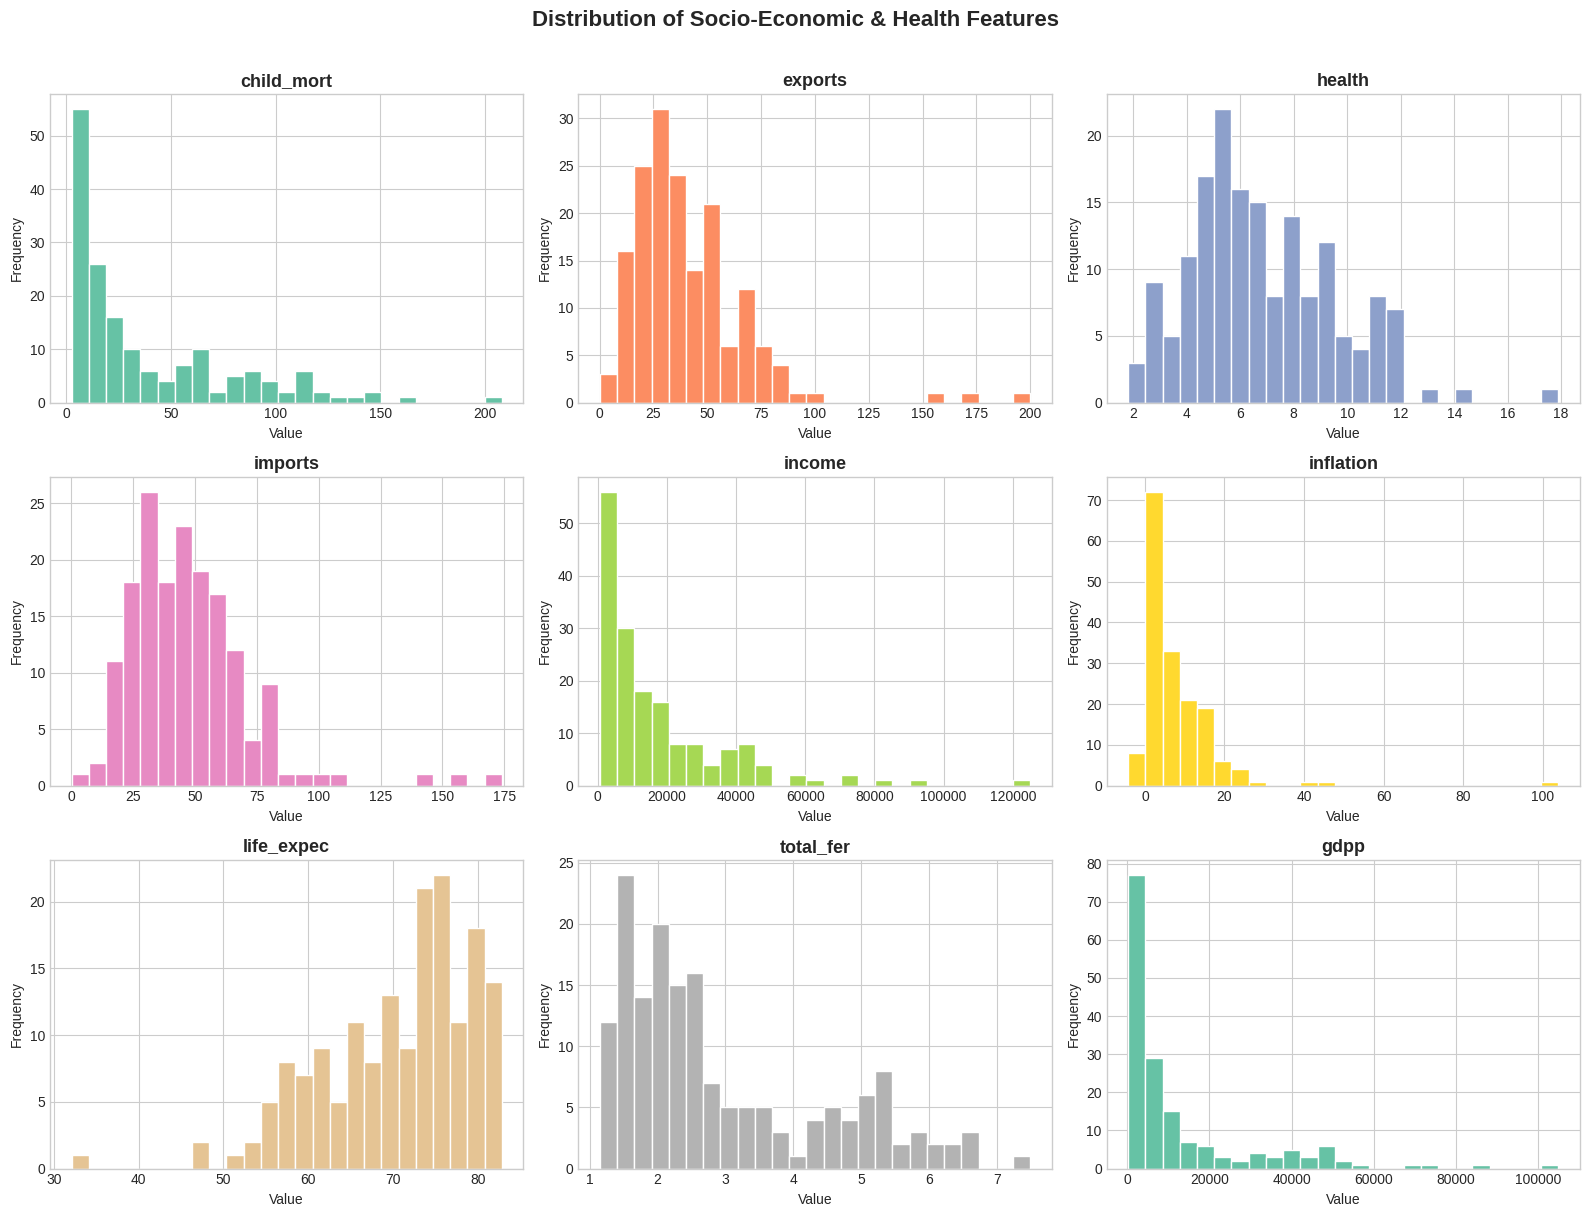

In [5]:
# Distribution of all numeric features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25, edgecolor='white', color=sns.color_palette('Set2')[i % 8])
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Socio-Economic & Health Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

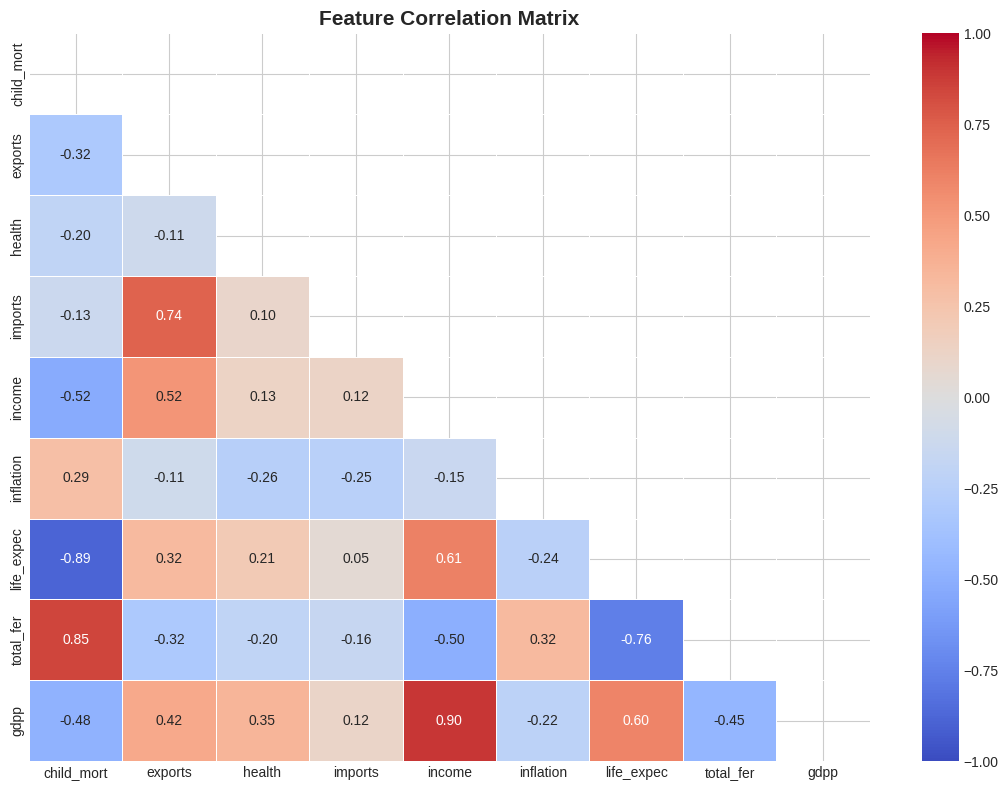

In [6]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

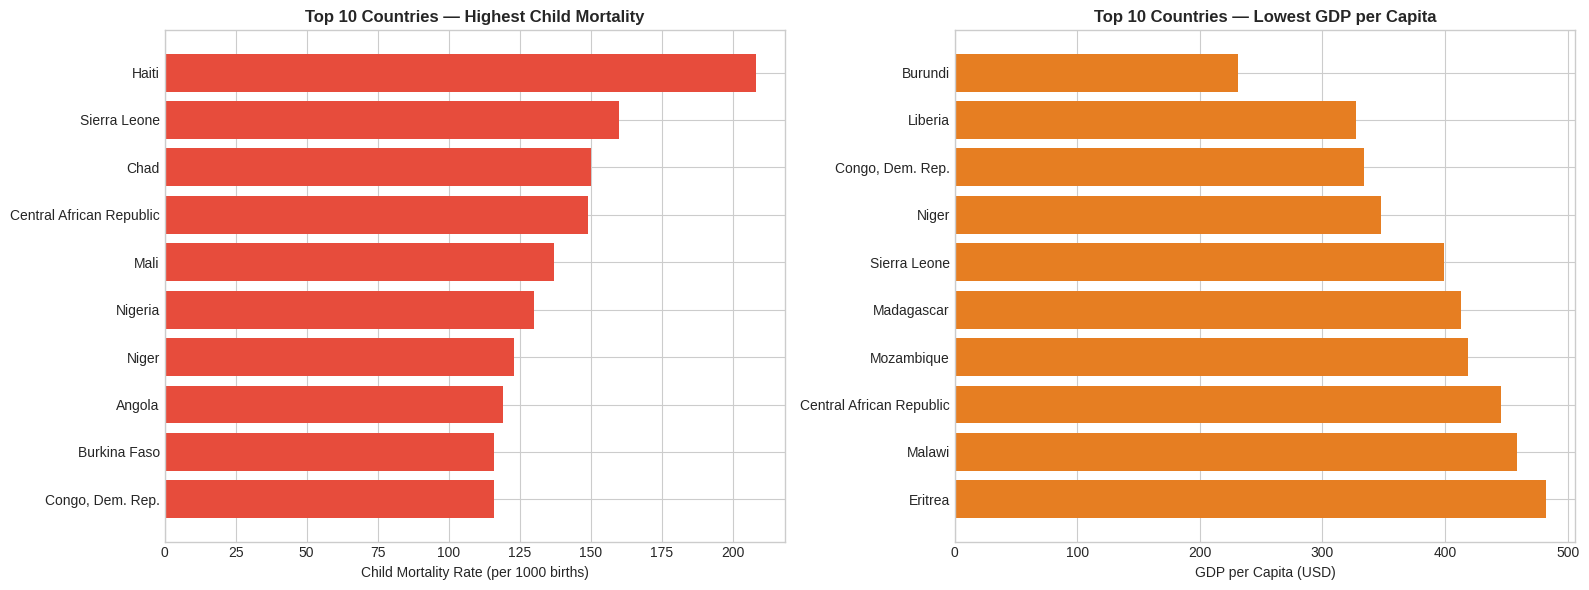

In [7]:
# Top 10 countries with highest child mortality
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_mort = df.nlargest(10, 'child_mort')[['country', 'child_mort']]
axes[0].barh(top_mort['country'], top_mort['child_mort'], color='#e74c3c')
axes[0].set_title('Top 10 Countries — Highest Child Mortality', fontweight='bold')
axes[0].set_xlabel('Child Mortality Rate (per 1000 births)')
axes[0].invert_yaxis()

# Bottom 10 by GDP per capita
bottom_gdp = df.nsmallest(10, 'gdpp')[['country', 'gdpp']]
axes[1].barh(bottom_gdp['country'], bottom_gdp['gdpp'], color='#e67e22')
axes[1].set_title('Top 10 Countries — Lowest GDP per Capita', fontweight='bold')
axes[1].set_xlabel('GDP per Capita (USD)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

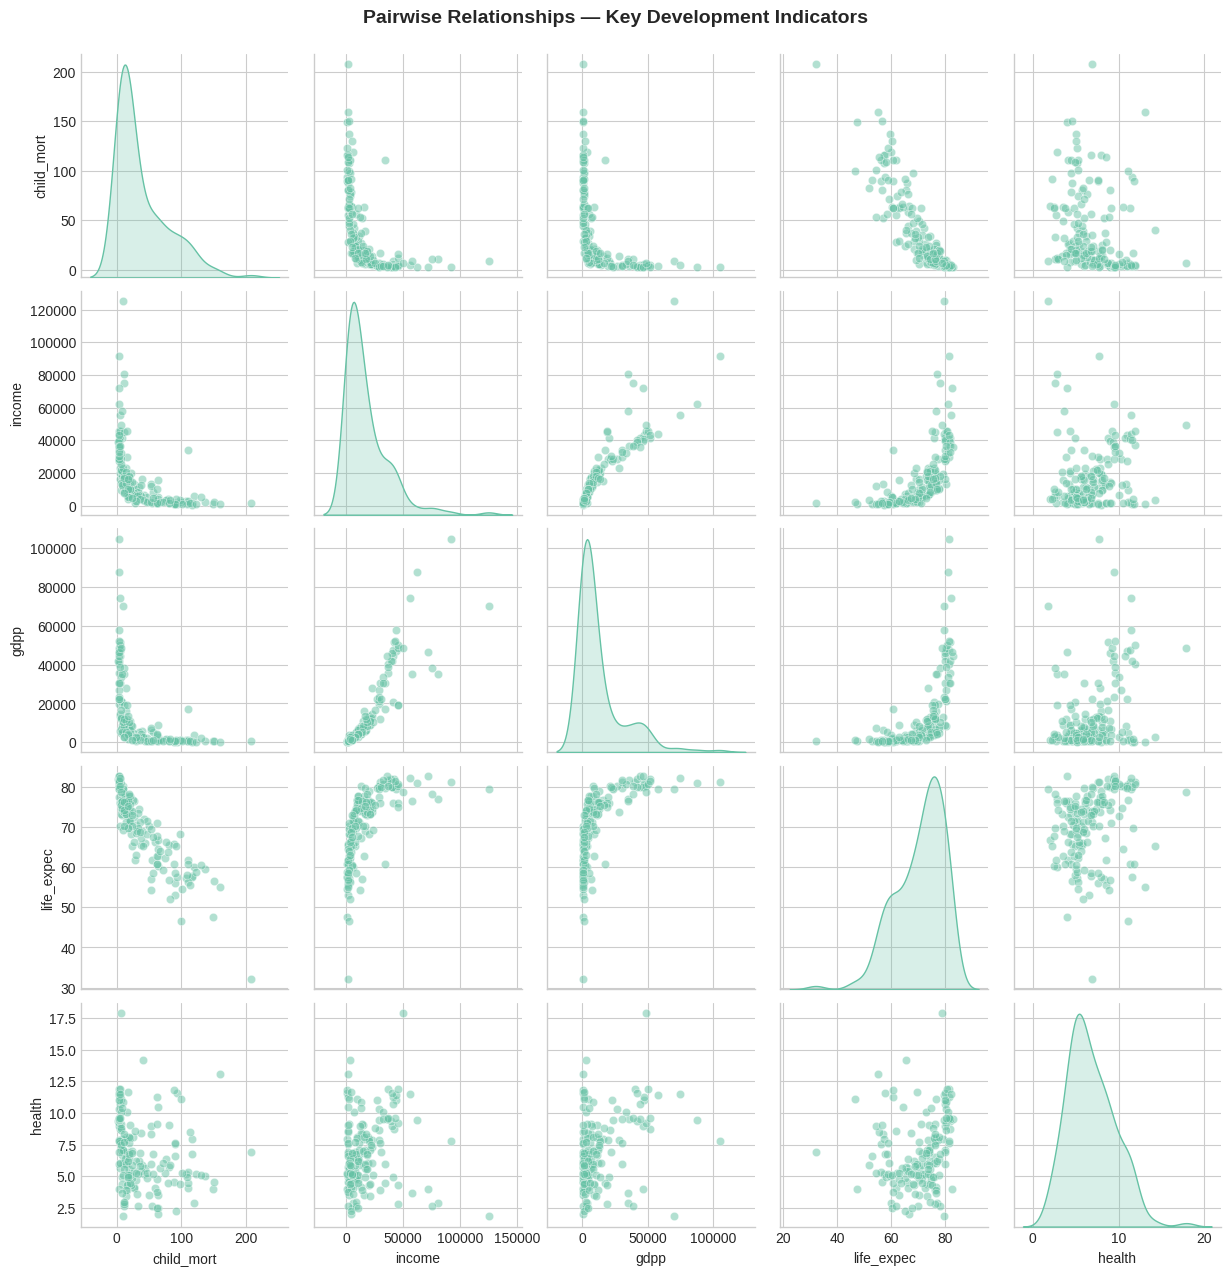

In [8]:
# Pairplot of key features
key_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'health']
sns.pairplot(df[key_features], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Relationships — Key Development Indicators', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Data Preprocessing

In [9]:
# Separate country names and features
country_names = df['country']
X = df.drop(columns=['country'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features after scaling (first 5 rows):")
print(X_scaled_df.head())
print(f"\nMean after scaling (should be ~0): {X_scaled_df.mean().round(4).values}")
print(f"Std after scaling (should be ~1): {X_scaled_df.std().round(4).values}")

Features after scaling (first 5 rows):
   child_mort   exports    health   imports    income  inflation  life_expec  \
0    1.291532 -1.138280  0.279088 -0.082455 -0.808245   0.157336   -1.619092   
1   -0.538949 -0.479658 -0.097016  0.070837 -0.375369  -0.312347    0.647866   
2   -0.272833 -0.099122 -0.966073 -0.641762 -0.220844   0.789274    0.670423   
3    2.007808  0.775381 -1.448071 -0.165315 -0.585043   1.387054   -1.179234   
4   -0.695634  0.160668 -0.286894  0.497568  0.101732  -0.601749    0.704258   

   total_fer      gdpp  
0   1.902882 -0.679180  
1  -0.859973 -0.485623  
2  -0.038404 -0.465376  
3   2.128151 -0.516268  
4  -0.541946 -0.041817  

Mean after scaling (should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std after scaling (should be ~1): [1.003 1.003 1.003 1.003 1.003 1.003 1.003 1.003 1.003]


## 5. Dimensionality Reduction — PCA

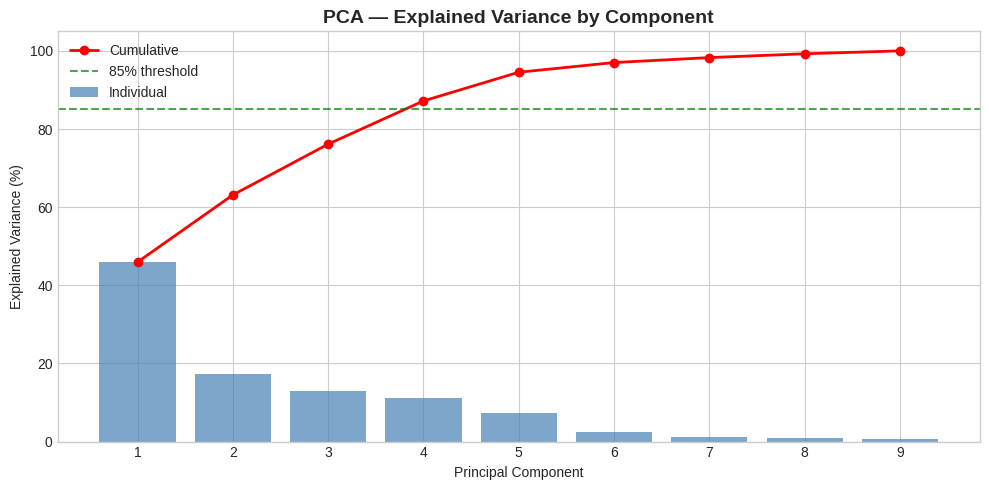

PC1: 45.95% variance | Cumulative: 45.95%
PC2: 17.18% variance | Cumulative: 63.13%
PC3: 13.00% variance | Cumulative: 76.14%
PC4: 11.05% variance | Cumulative: 87.19%
PC5: 7.34% variance | Cumulative: 94.53%
PC6: 2.48% variance | Cumulative: 97.02%
PC7: 1.26% variance | Cumulative: 98.28%
PC8: 0.98% variance | Cumulative: 99.26%
PC9: 0.74% variance | Cumulative: 100.00%


In [10]:
# PCA to understand variance
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained)+1), explained * 100, alpha=0.7, label='Individual', color='steelblue')
plt.plot(range(1, len(cumulative)+1), cumulative * 100, 'r-o', label='Cumulative', linewidth=2)
plt.axhline(y=85, color='green', linestyle='--', alpha=0.7, label='85% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA — Explained Variance by Component', fontsize=14, fontweight='bold')
plt.legend()
plt.xticks(range(1, len(explained)+1))
plt.tight_layout()
plt.show()

for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f"PC{i+1}: {e*100:.2f}% variance | Cumulative: {c*100:.2f}%")

In [11]:
# Reduce to 2D for visualization, keep 3 components for clustering
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"Variance captured by 2 components: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Variance captured by 3 components: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

Variance captured by 2 components: 63.13%
Variance captured by 3 components: 76.14%


## 6. Clustering — K-Means

K-Means is applied first as the primary clustering approach. We'll use the Elbow Method and Silhouette Score to find the optimal number of clusters.

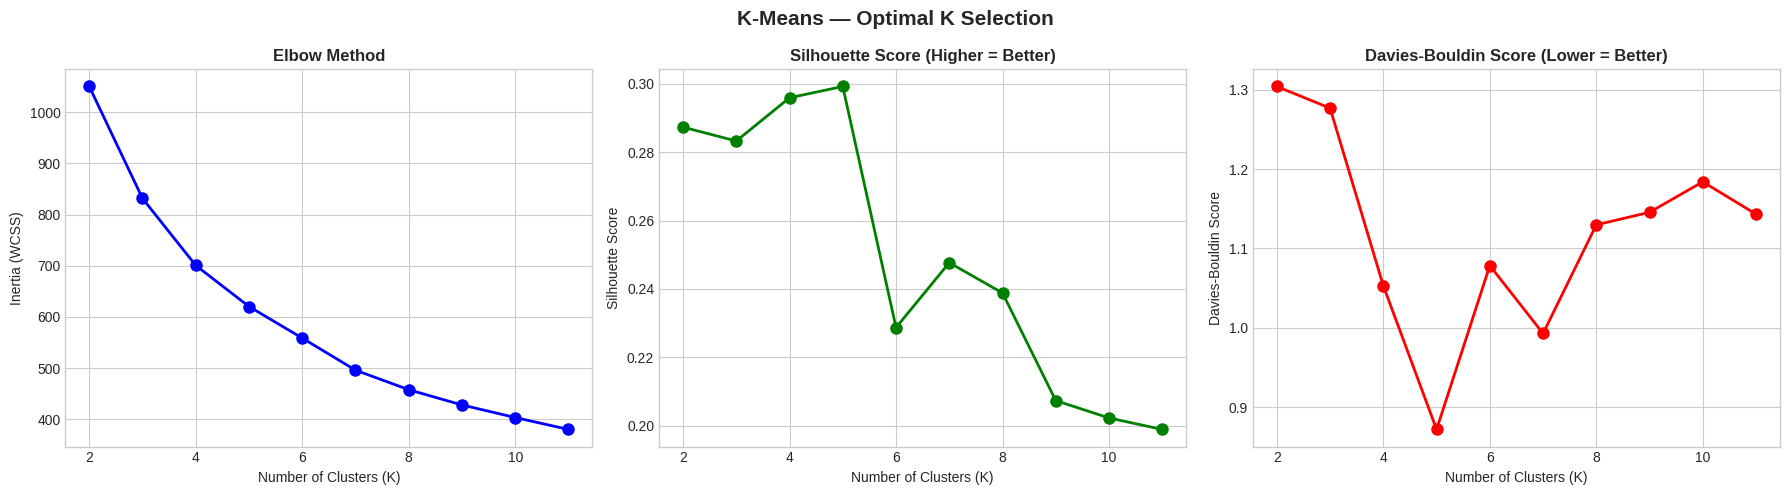

Best K by Silhouette Score: 5
Silhouette Score at K=5: 0.2993


In [12]:
# Elbow Method
inertias = []
silhouette_scores = []
db_scores = []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(K_range, inertias, 'b-o', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method', fontweight='bold')

axes[1].plot(K_range, silhouette_scores, 'g-o', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Higher = Better)', fontweight='bold')

axes[2].plot(K_range, db_scores, 'r-o', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (Lower = Better)', fontweight='bold')

plt.suptitle('K-Means — Optimal K Selection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f"Best K by Silhouette Score: {best_k}")
print(f"Silhouette Score at K={best_k}: {max(silhouette_scores):.4f}")

In [13]:
# Final K-Means model with optimal k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=15, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print(f"K-Means with K={optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}")
print(f"\nCluster distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

K-Means with K=3
Silhouette Score: 0.2833
Davies-Bouldin Score: 1.2769

Cluster distribution:
KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64


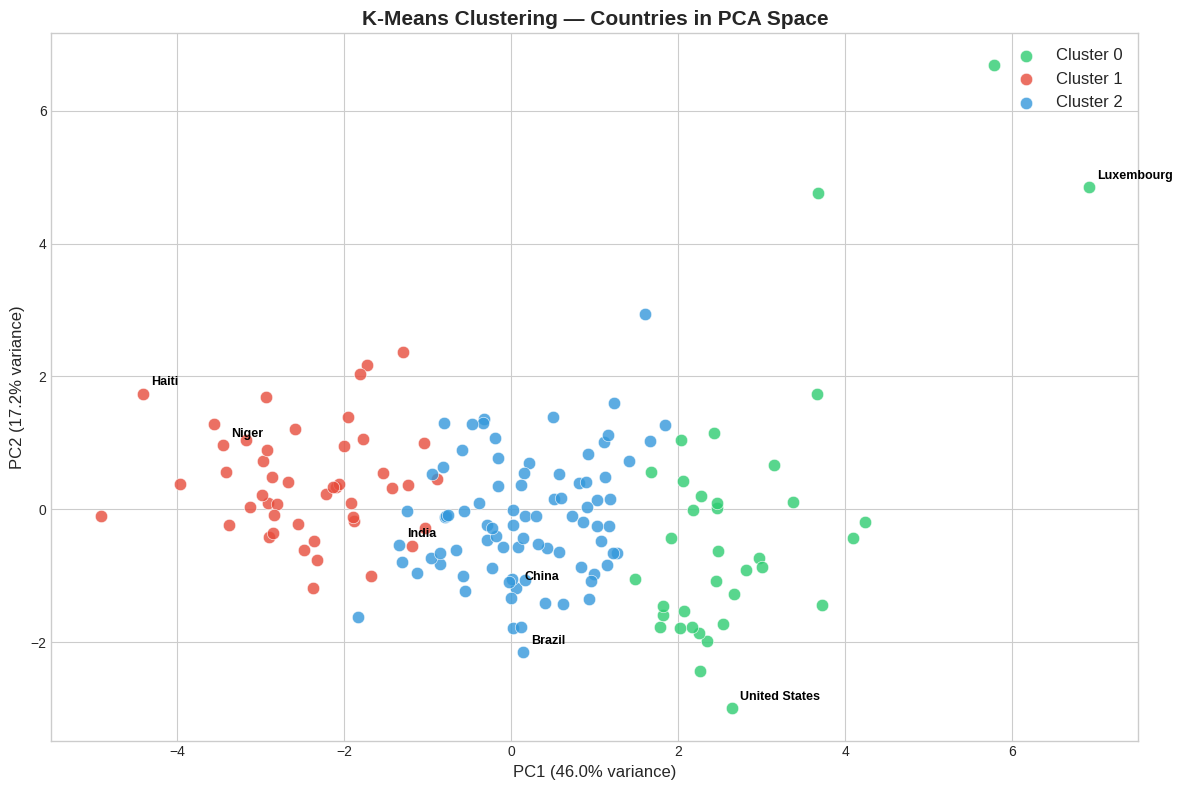

In [14]:
# Visualize K-Means clusters in 2D PCA space
cluster_colors = ['#2ecc71', '#e74c3c', '#3498db']
cluster_labels_map = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

plt.figure(figsize=(12, 8))
for cluster in range(optimal_k):
    mask = kmeans_labels == cluster
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=cluster_colors[cluster], label=f'Cluster {cluster}',
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

# Annotate some notable countries
notable = ['Haiti', 'Niger', 'United States', 'Luxembourg', 'China', 'India', 'Brazil', 'Somalia']
for i, country in enumerate(df['country']):
    if country in notable:
        plt.annotate(country, (X_pca_2d[i, 0], X_pca_2d[i, 1]),
                     textcoords='offset points', xytext=(6, 6), fontsize=9,
                     fontweight='bold', color='black')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('K-Means Clustering — Countries in PCA Space', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

=== K-Means Cluster Profiles (Mean Values) ===
KMeans_Cluster         0        1         2
child_mort          5.00    92.96     21.93
exports            58.74    29.15     40.24
health              8.81     6.39      6.20
imports            51.49    42.32     47.47
income          45672.22  3942.40  12305.60
inflation           2.67    12.02      7.60
life_expec         80.13    59.19     72.81
total_fer           1.75     5.01      2.31
gdpp            42494.44  1922.38   6486.45


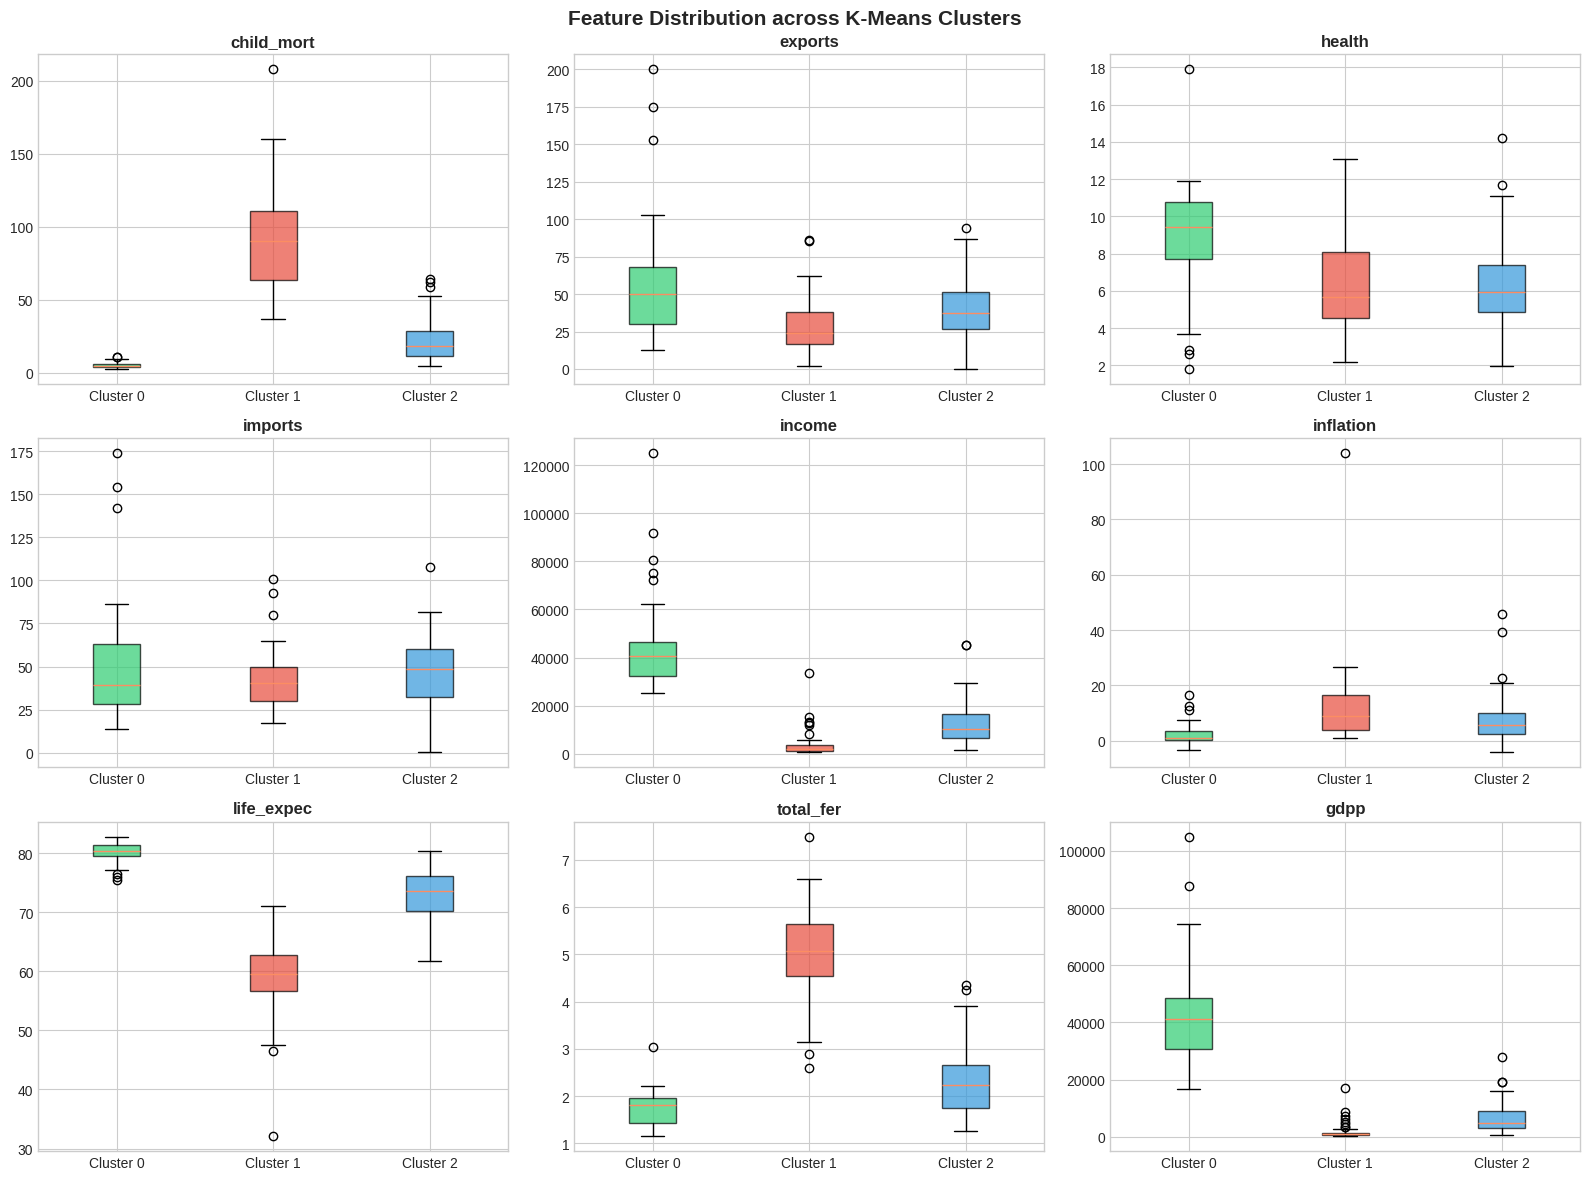

In [15]:
# Cluster profiling
cluster_profile = df.groupby('KMeans_Cluster')[numeric_cols].mean().round(2)
print("=== K-Means Cluster Profiles (Mean Values) ===")
print(cluster_profile.T)

# Visualize cluster profiles
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    vals = [df[df['KMeans_Cluster'] == c][col].values for c in range(optimal_k)]
    bp = axes[i].boxplot(vals, patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], cluster_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticklabels([f'Cluster {c}' for c in range(optimal_k)])

plt.suptitle('Feature Distribution across K-Means Clusters', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Clustering — DBSCAN

DBSCAN is a density-based algorithm that does not require specifying the number of clusters. It also identifies outliers as noise, which can be particularly useful for finding anomalous countries.

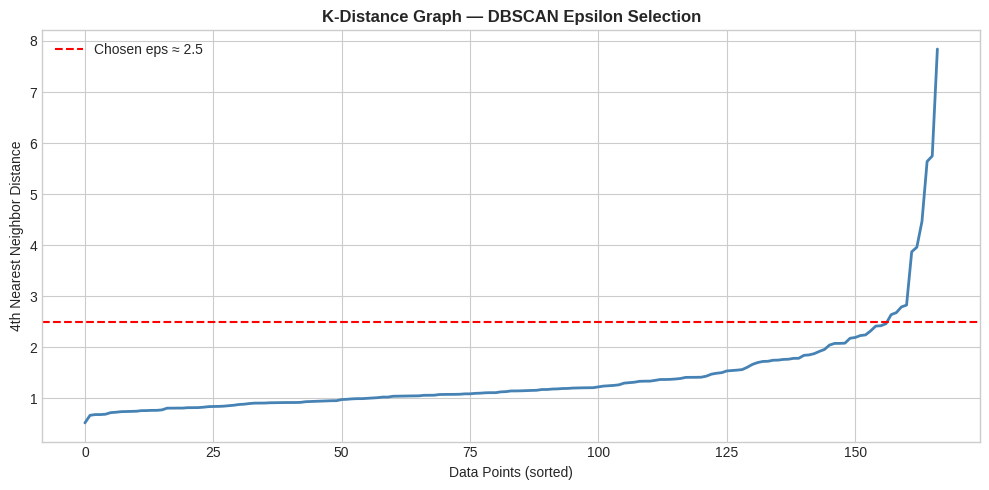

In [16]:
from sklearn.neighbors import NearestNeighbors

# Find optimal epsilon using k-distance graph
neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, linewidth=2, color='steelblue')
plt.xlabel('Data Points (sorted)')
plt.ylabel('4th Nearest Neighbor Distance')
plt.title('K-Distance Graph — DBSCAN Epsilon Selection', fontweight='bold')
plt.axhline(y=2.5, color='red', linestyle='--', label='Chosen eps ≈ 2.5')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# DBSCAN clustering
dbscan = DBSCAN(eps=2.5, min_samples=4)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN Results:")
print(f"  Number of clusters found: {n_clusters}")
print(f"  Noise points (outliers): {n_noise}")
print(f"  Cluster distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

if n_clusters > 1:
    mask_no_noise = dbscan_labels != -1
    sil = silhouette_score(X_scaled[mask_no_noise], dbscan_labels[mask_no_noise])
    print(f"\nSilhouette Score (excluding noise): {sil:.4f}")

# Outlier countries
outlier_countries = df[df['DBSCAN_Cluster'] == -1]['country'].tolist()
print(f"\nOutlier/Noise countries: {outlier_countries}")

DBSCAN Results:
  Number of clusters found: 1
  Noise points (outliers): 6
  Cluster distribution:
-1      6
 0    161
Name: count, dtype: int64

Outlier/Noise countries: ['Haiti', 'Luxembourg', 'Malta', 'Nigeria', 'Qatar', 'Singapore']


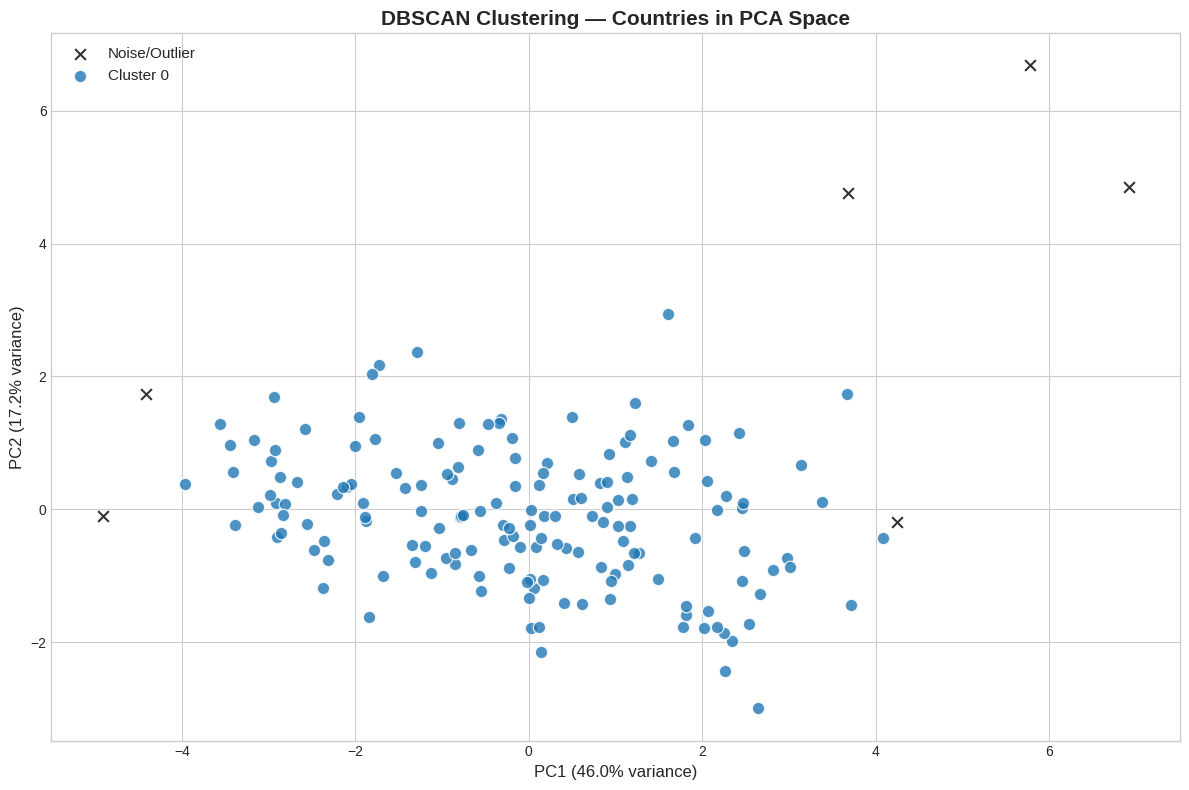

In [18]:
# Visualize DBSCAN clusters
unique_labels = sorted(set(dbscan_labels))
palette = sns.color_palette('tab10', n_colors=max(n_clusters, 1))

plt.figure(figsize=(12, 8))
for label in unique_labels:
    mask = dbscan_labels == label
    color = 'black' if label == -1 else palette[label]
    name = 'Noise/Outlier' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=[color], label=name, s=80 if label != -1 else 60,
                alpha=0.8, marker=marker, edgecolors='white' if label != -1 else None)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('DBSCAN Clustering — Countries in PCA Space', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 8. Cluster Interpretation & Country Segmentation

In [19]:
# Assign meaningful labels to K-Means clusters based on their profiles
# Cluster with highest child_mort and lowest gdpp = Underdeveloped
# Cluster with medium values = Developing
# Cluster with lowest child_mort and highest gdpp = Developed

cluster_avg = df.groupby('KMeans_Cluster')[['child_mort', 'gdpp', 'income', 'life_expec']].mean()
print("Cluster Averages for Labeling:")
print(cluster_avg)

# Sort clusters by gdpp to assign labels
gdpp_rank = cluster_avg['gdpp'].rank()
label_map = {}
for idx in gdpp_rank.index:
    rank = gdpp_rank[idx]
    if rank == 1:
        label_map[idx] = 'Underdeveloped'
    elif rank == 2:
        label_map[idx] = 'Developing'
    else:
        label_map[idx] = 'Developed'

df['Development_Stage'] = df['KMeans_Cluster'].map(label_map)
print("\nCluster Label Mapping:", label_map)
print("\nCountries per Development Stage:")
print(df['Development_Stage'].value_counts())

Cluster Averages for Labeling:
                child_mort          gdpp        income  life_expec
KMeans_Cluster                                                    
0                 5.000000  42494.444444  45672.222222   80.127778
1                92.961702   1922.382979   3942.404255   59.187234
2                21.927381   6486.452381  12305.595238   72.814286

Cluster Label Mapping: {0: 'Developed', 1: 'Underdeveloped', 2: 'Developing'}

Countries per Development Stage:
Development_Stage
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64


In [20]:
# Countries most in need of aid (Underdeveloped cluster)
underdeveloped = df[df['Development_Stage'] == 'Underdeveloped'].copy()
underdeveloped_sorted = underdeveloped.sort_values(['child_mort'], ascending=False)

print("=== Countries Most in Need of Aid (Underdeveloped Cluster) ===")
print(underdeveloped_sorted[['country', 'child_mort', 'income', 'gdpp', 'life_expec']].to_string(index=False))

print(f"\nTop 10 countries CEO should prioritize:")
print(underdeveloped_sorted[['country', 'child_mort', 'gdpp']].head(10).to_string(index=False))

=== Countries Most in Need of Aid (Underdeveloped Cluster) ===
                 country  child_mort  income  gdpp  life_expec
                   Haiti       208.0    1500   662        32.1
            Sierra Leone       160.0    1220   399        55.0
                    Chad       150.0    1930   897        56.5
Central African Republic       149.0     888   446        47.5
                    Mali       137.0    1870   708        59.5
                 Nigeria       130.0    5150  2330        60.5
                   Niger       123.0     814   348        58.8
                  Angola       119.0    5900  3530        60.1
            Burkina Faso       116.0    1430   575        57.9
        Congo, Dem. Rep.       116.0     609   334        57.5
           Guinea-Bissau       114.0    1390   547        55.6
       Equatorial Guinea       111.0   33700 17100        60.9
                   Benin       111.0    1820   758        61.8
           Cote d'Ivoire       111.0    2690  1220     

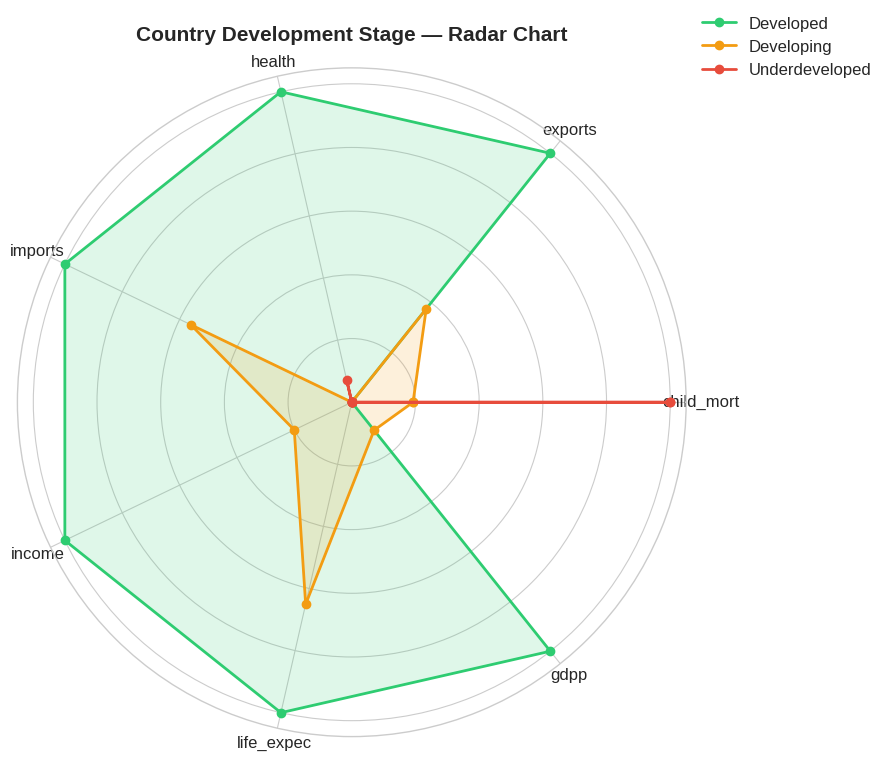

In [21]:
# Radar chart comparing cluster profiles
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

features_radar = ['child_mort', 'exports', 'health', 'imports', 'income', 'life_expec', 'gdpp']
cluster_means = df.groupby('Development_Stage')[features_radar].mean()

# Normalize to 0-1 for radar
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
cluster_means_norm = pd.DataFrame(
    mms.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

N = len(features_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_radar = {'Underdeveloped': '#e74c3c', 'Developing': '#f39c12', 'Developed': '#2ecc71'}

for stage, row in cluster_means_norm.iterrows():
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=stage, color=colors_radar.get(stage, 'gray'))
    ax.fill(angles, values, alpha=0.15, color=colors_radar.get(stage, 'gray'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features_radar, fontsize=12)
ax.set_yticklabels([])
ax.set_title('Country Development Stage — Radar Chart', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.tight_layout()
plt.show()

## 9. Classification using Ensemble Models

Using the K-Means cluster labels as the target variable, we now train ensemble classifiers (Random Forest, XGBoost, AdaBoost, Gradient Boosting) to understand which features drive country classification. This also allows us to predict the development stage for new countries.

In [22]:
# Prepare classification data
X_clf = df[numeric_cols].copy()
y_clf = df['KMeans_Cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution (Train):")
print(pd.Series(y_train).value_counts())

Training set: (133, 9)
Test set: (34, 9)

Class distribution (Train):
2    67
1    37
0    29
Name: count, dtype: int64


In [23]:
# Define models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=150, learning_rate=0.8, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                      learning_rate=0.1, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_clf, y_clf, cv=5, scoring='accuracy')
    results[name] = {
        'model': model,
        'accuracy': acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred
    }
    print(f"{name}: Test Accuracy = {acc:.4f} | CV = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Random Forest: Test Accuracy = 1.0000 | CV = 0.9578 ± 0.0310
XGBoost: Test Accuracy = 0.9706 | CV = 0.9579 ± 0.0240
AdaBoost: Test Accuracy = 0.9706 | CV = 0.9636 ± 0.0297
Gradient Boosting: Test Accuracy = 0.9706 | CV = 0.9458 ± 0.0353


In [24]:
# Stacking Ensemble
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)
cv_stack = cross_val_score(stacking_clf, X_clf, y_clf, cv=5, scoring='accuracy')
results['Stacking'] = {
    'model': stacking_clf,
    'accuracy': acc_stack,
    'cv_mean': cv_stack.mean(),
    'cv_std': cv_stack.std(),
    'predictions': y_pred_stack
}
print(f"Stacking Ensemble: Test Accuracy = {acc_stack:.4f} | CV = {cv_stack.mean():.4f} ± {cv_stack.std():.4f}")

Stacking Ensemble: Test Accuracy = 0.9706 | CV = 0.9640 ± 0.0351


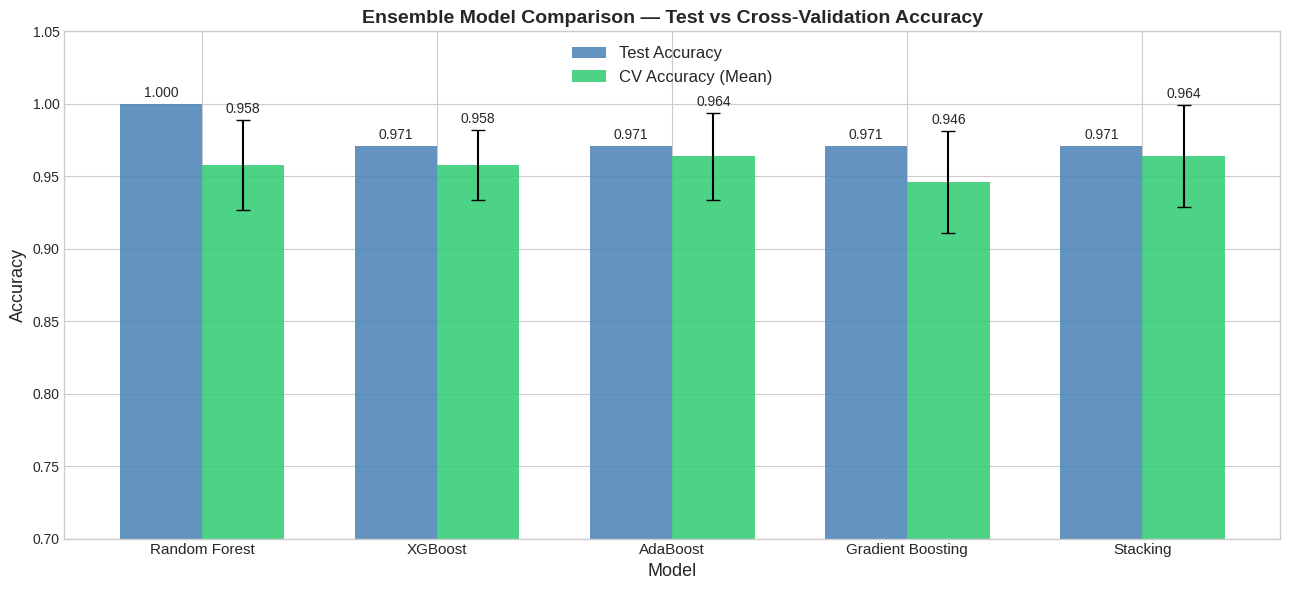

In [25]:
# Model comparison plot
model_names = list(results.keys())
test_accs = [results[m]['accuracy'] for m in model_names]
cv_means = [results[m]['cv_mean'] for m in model_names]
cv_stds = [results[m]['cv_std'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, cv_means, width, label='CV Accuracy (Mean)', color='#2ecc71', alpha=0.85,
               yerr=cv_stds, capsize=5)

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Ensemble Model Comparison — Test vs Cross-Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=12)
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=10)
plt.tight_layout()
plt.show()

In [26]:
# Best model classification report
best_model_name = max(results, key=lambda m: results[m]['cv_mean'])
best_model = results[best_model_name]
print(f"=== Best Model: {best_model_name} ===")
print(f"Test Accuracy: {best_model['accuracy']:.4f}")
print("\nClassification Report:")
stage_names = [label_map.get(i, str(i)) for i in range(optimal_k)]
print(classification_report(y_test, best_model['predictions'], target_names=stage_names))

=== Best Model: Stacking ===
Test Accuracy: 0.9706

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      0.90      0.95        10
    Developing       0.94      1.00      0.97        17

      accuracy                           0.97        34
     macro avg       0.98      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



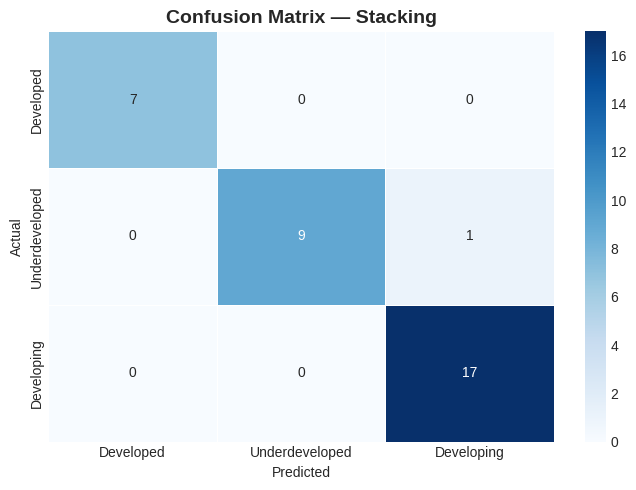

In [27]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, best_model['predictions'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names,
            linewidths=0.5)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

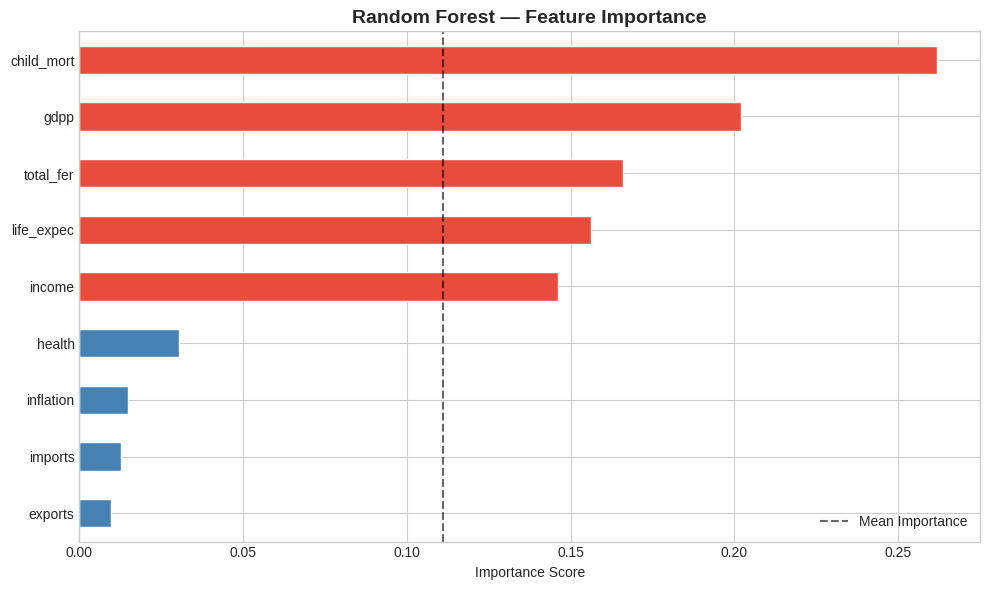

Top 5 most important features:
child_mort    0.261935
gdpp          0.202125
total_fer     0.165920
life_expec    0.156307
income        0.146203
dtype: float64


In [28]:
# Feature Importance from Random Forest
rf_model = results['Random Forest']['model']
feature_importance = pd.Series(rf_model.feature_importances_, index=numeric_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors_fi = ['#e74c3c' if v > feature_importance.mean() else 'steelblue' for v in feature_importance.values]
feature_importance.plot(kind='barh', color=colors_fi, edgecolor='white')
plt.axvline(x=feature_importance.mean(), color='black', linestyle='--', alpha=0.6, label='Mean Importance')
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feature_importance.sort_values(ascending=False).head())

## 10. Model Evaluation Summary

In [29]:
print("=" * 65)
print("           COMPLETE MODEL EVALUATION SUMMARY")
print("=" * 65)
print(f"{'Model':<22} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 55)
for name, res in results.items():
    print(f"{name:<22} {res['accuracy']:>10.4f} {res['cv_mean']:>10.4f} {res['cv_std']:>10.4f}")
print("-" * 55)
print(f"\nClustering Results:")
print(f"  K-Means (K=3) Silhouette Score : {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"  K-Means (K=3) DB Score         : {davies_bouldin_score(X_scaled, kmeans_labels):.4f}")
if n_clusters > 1:
    print(f"  DBSCAN Clusters Found          : {n_clusters}")
    print(f"  DBSCAN Noise/Outlier Points    : {n_noise}")
print("=" * 65)

           COMPLETE MODEL EVALUATION SUMMARY
Model                    Test Acc    CV Mean     CV Std
-------------------------------------------------------
Random Forest              1.0000     0.9578     0.0310
XGBoost                    0.9706     0.9579     0.0240
AdaBoost                   0.9706     0.9636     0.0297
Gradient Boosting          0.9706     0.9458     0.0353
Stacking                   0.9706     0.9640     0.0351
-------------------------------------------------------

Clustering Results:
  K-Means (K=3) Silhouette Score : 0.2833
  K-Means (K=3) DB Score         : 1.2769


## 11. Business Insights & Recommendations

In [30]:
print("=" * 65)
print("  HELP INTERNATIONAL — AID ALLOCATION RECOMMENDATIONS")
print("=" * 65)

for stage in ['Underdeveloped', 'Developing', 'Developed']:
    subset = df[df['Development_Stage'] == stage]
    print(f"\n--- {stage} Countries ({len(subset)} total) ---")
    print(f"  Avg Child Mortality : {subset['child_mort'].mean():.1f} per 1000 births")
    print(f"  Avg GDP per Capita  : ${subset['gdpp'].mean():,.0f}")
    print(f"  Avg Income          : ${subset['income'].mean():,.0f}")
    print(f"  Avg Life Expectancy : {subset['life_expec'].mean():.1f} years")

print("\n" + "=" * 65)
print("TOP 15 COUNTRIES REQUIRING IMMEDIATE AID:")
print("=" * 65)
top_aid = df[df['Development_Stage'] == 'Underdeveloped'].nlargest(15, 'child_mort')
print(top_aid[['country', 'child_mort', 'gdpp', 'income', 'life_expec']].to_string(index=False))

print("\n" + "=" * 65)
print("KEY INSIGHTS:")
print("=" * 65)
print("1. child_mort and gdpp are the most discriminative features.")
print("2. Countries in the Underdeveloped cluster have child mortality")
print("   rates 10-40x higher than developed nations.")
print("3. DBSCAN identified outlier countries with extreme indicators.")
print("4. Random Forest & XGBoost both achieve high accuracy, confirming")
print("   that clusters are well-separated and meaningful.")
print("5. CEO should prioritize Sub-Saharan Africa based on clustering.")
print("=" * 65)

  HELP INTERNATIONAL — AID ALLOCATION RECOMMENDATIONS

--- Underdeveloped Countries (47 total) ---
  Avg Child Mortality : 93.0 per 1000 births
  Avg GDP per Capita  : $1,922
  Avg Income          : $3,942
  Avg Life Expectancy : 59.2 years

--- Developing Countries (84 total) ---
  Avg Child Mortality : 21.9 per 1000 births
  Avg GDP per Capita  : $6,486
  Avg Income          : $12,306
  Avg Life Expectancy : 72.8 years

--- Developed Countries (36 total) ---
  Avg Child Mortality : 5.0 per 1000 births
  Avg GDP per Capita  : $42,494
  Avg Income          : $45,672
  Avg Life Expectancy : 80.1 years

TOP 15 COUNTRIES REQUIRING IMMEDIATE AID:
                 country  child_mort  gdpp  income  life_expec
                   Haiti       208.0   662    1500        32.1
            Sierra Leone       160.0   399    1220        55.0
                    Chad       150.0   897    1930        56.5
Central African Republic       149.0   446     888        47.5
                    Mali       137

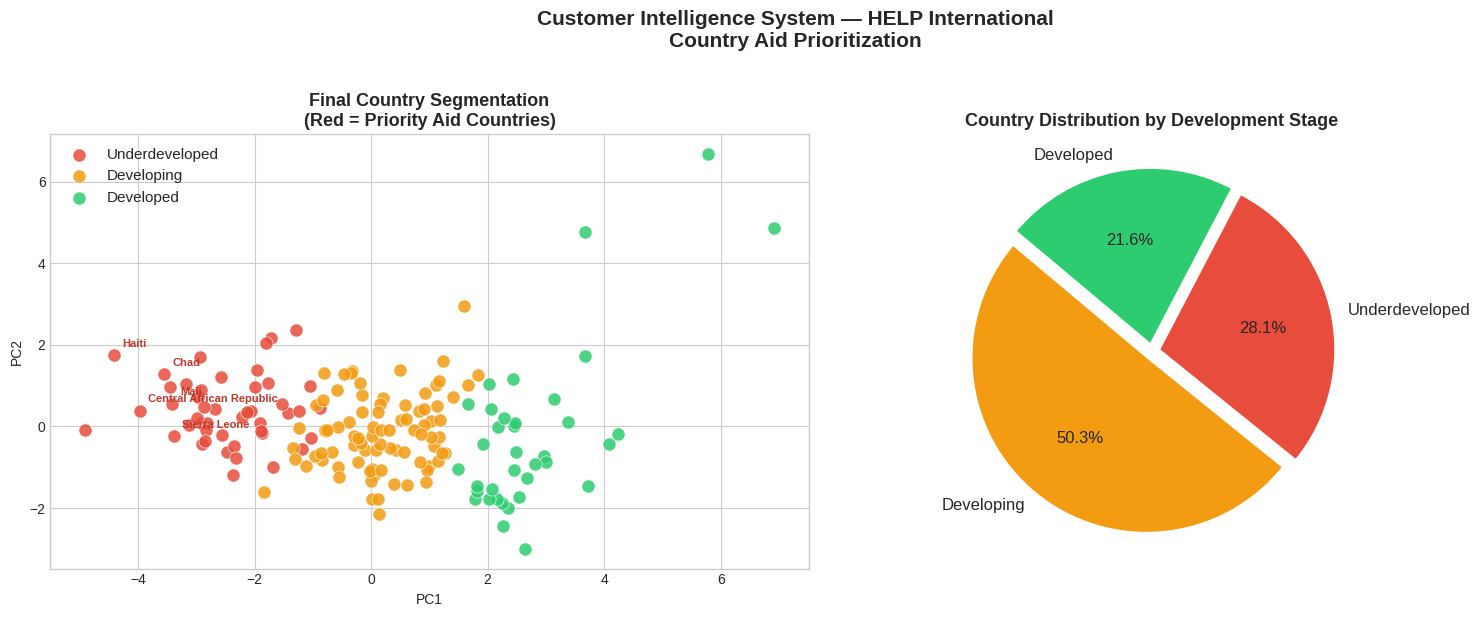


✓ Customer Intelligence System complete.
✓ Clusters: K-Means (K=3) + DBSCAN
✓ Classifiers: Random Forest, XGBoost, AdaBoost, Gradient Boosting, Stacking
✓ Recommendation: Prioritize Underdeveloped cluster countries for immediate aid.


In [31]:
# Final visualization — development stage world view
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

stage_colors = {'Underdeveloped': '#e74c3c', 'Developing': '#f39c12', 'Developed': '#2ecc71'}
for stage in ['Underdeveloped', 'Developing', 'Developed']:
    mask = df['Development_Stage'] == stage
    axes[0].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=stage_colors[stage], label=stage, s=90, alpha=0.85,
        edgecolors='white', linewidth=0.5
    )

# Annotate top aid countries
top_aid_countries = top_aid['country'].head(5).tolist()
for i, row in df.iterrows():
    if row['country'] in top_aid_countries:
        axes[0].annotate(row['country'], (X_pca_2d[i, 0], X_pca_2d[i, 1]),
                         textcoords='offset points', xytext=(6, 6), fontsize=8,
                         color='#c0392b', fontweight='bold')

axes[0].set_title('Final Country Segmentation\n(Red = Priority Aid Countries)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=11)

# Pie chart
stage_counts = df['Development_Stage'].value_counts()
axes[1].pie(
    stage_counts.values,
    labels=stage_counts.index,
    colors=[stage_colors[s] for s in stage_counts.index],
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 12}, explode=[0.05]*len(stage_counts)
)
axes[1].set_title('Country Distribution by Development Stage', fontweight='bold', fontsize=13)

plt.suptitle('Customer Intelligence System — HELP International\nCountry Aid Prioritization',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Customer Intelligence System complete.")
print("✓ Clusters: K-Means (K=3) + DBSCAN")
print("✓ Classifiers: Random Forest, XGBoost, AdaBoost, Gradient Boosting, Stacking")
print("✓ Recommendation: Prioritize Underdeveloped cluster countries for immediate aid.")